# BASELINE MODEL BUILDING 

DATA MANIPULATION, DATA VIZUALIZATION, AND MACHINE LEARNING & PREPROCESSING

In [254]:
# DATA MANIPULATION
import pandas as pd
import numpy as np
import os 

# DATA VIZUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# MACHINE LEARNING & PREPROCESSING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.neighbors import KNeighborsClassifier 
from pathlib import Path

# LOADED DATASET 

In [255]:
DATA_PATH = Path('income_evaluation.csv')

if not DATA_PATH.exists():
    raise FileNotFoundError(f'{DATA_PATH} not found')
df = pd.read_csv('income_evaluation.csv')
print(f'LOADED DATA: {df.shape}')

LOADED DATA: (32561, 15)


In [256]:
# Initial data inspection 
print('--- Dataset Shape ---')
print(df.shape)

# Display First 5 Rows 
print('\n --- First 5 Rows ---')
display(df.head())

# Data Information 
print('\n --- Data Information ---')
print(df.info())

--- Dataset Shape ---
(32561, 15)

 --- First 5 Rows ---


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516.0,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311.0,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13,United-States,<=50K
2,38,Private,215646.0,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40,United-States,<=50K
3,53,Private,234721.0,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40,United-States,<=50K
4,28,Private,338409.0,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40,Cuba,<=50K



 --- Data Information ---
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32561 non-null  int64  
 1   workclass       32561 non-null  str    
 2   fnlwgt          32559 non-null  float64
 3   education       32561 non-null  str    
 4   education-num   32561 non-null  int64  
 5   marital-status  32561 non-null  str    
 6   occupation      32561 non-null  str    
 7   relationship    32561 non-null  str    
 8   race            32561 non-null  str    
 9   sex             32561 non-null  str    
 10  capital-gain    32558 non-null  float64
 11  capital-loss    32556 non-null  float64
 12  hours-per-week  32561 non-null  int64  
 13  native-country  32561 non-null  str    
 14  income          32555 non-null  str    
dtypes: float64(3), int64(3), str(9)
memory usage: 3.7 MB
None


In [257]:
# MISSING VALUES
df.isna().sum()

age               0
workclass         0
fnlwgt            2
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      3
capital-loss      5
hours-per-week    0
native-country    0
income            6
dtype: int64

# DATA CLEANING: DATA PREPROCESSING 

HANDLING MISSING VALUES 

In [258]:
def handle_miss_vals(df):
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == 'str':
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].median())
    return df
handle_miss_vals(df)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516.0,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311.0,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13,United-States,<=50K
2,38,Private,215646.0,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40,United-States,<=50K
3,53,Private,234721.0,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40,United-States,<=50K
4,28,Private,338409.0,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302.0,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0.0,0.0,38,United-States,<=50K
32557,40,Private,154374.0,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,40,United-States,>50K
32558,58,Private,151910.0,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0.0,0.0,40,United-States,<=50K
32559,22,Private,201490.0,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0.0,0.0,20,United-States,<=50K


In [259]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [260]:
df.nunique()

age                  73
workclass             9
fnlwgt            21647
education            17
education-num        16
marital-status        8
occupation           16
relationship          7
race                  6
sex                   3
capital-gain        119
capital-loss         92
hours-per-week       94
native-country       43
income                3
dtype: int64

ENCODING: USING LABEL ENCODER

In [261]:
def encodla(df, target = 'income'):
    y = df[target]
    X = df.drop(target, axis=1)
    
    
    for col in X.columns:
        if X[col].dtype == 'str':
            if X[col].nunique() <=5:
                dummies = pd.get_dummies(X[col], prefix=col, dtype=int)
                X = pd.concat([X.drop(columns=col), dummies], axis=1)
            else:
                le = LabelEncoder()
                X[col] = le.fit_transform(X[col])
    
    if y.dtype == 'str':
        le = LabelEncoder()
        y = le.fit_transform(y)
    df_encoded = pd.concat([X, pd.Series(y, name=target)], axis=1)
    return df_encoded
df_encoded = encodla(df, target='income')


In [262]:

df = df_encoded
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32561 non-null  int64  
 1   workclass       32561 non-null  int64  
 2   fnlwgt          32561 non-null  float64
 3   education       32561 non-null  int64  
 4   education-num   32561 non-null  int64  
 5   marital-status  32561 non-null  int64  
 6   occupation      32561 non-null  int64  
 7   relationship    32561 non-null  int64  
 8   race            32561 non-null  int64  
 9   capital-gain    32561 non-null  float64
 10  capital-loss    32561 non-null  float64
 11  hours-per-week  32561 non-null  int64  
 12  native-country  32561 non-null  int64  
 13  sex_            32561 non-null  int64  
 14  sex_ Female     32561 non-null  int64  
 15  sex_ Male       32561 non-null  int64  
 16  income          32561 non-null  int64  
dtypes: float64(3), int64(14)
memory usage: 4.2

# TRAIN TEST SPLIT

In [263]:
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# MODEL TRAINING 

1. DECISION TREE CLASSIFIER
2. RANDOM FOREST CLASSIFIER
3. XGBOOST CLASSIFIER


In [264]:
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
xgb_class = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1, 
    max_depth=3, 
    subsample=1, 
    colsample_bytree= 0.8, 
    random_state=42
)

In [265]:
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [266]:
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [267]:
xgb_class.fit(X_train, y_train)
y_pred_xgb_class = xgb_class.predict(X_test)

# EVALUATION METRICS

In [268]:
# DECISION TREE 
class_report = accuracy_score(y_test, y_pred_dt)
con_matrix = confusion_matrix(y_test, y_pred_dt)
print(f"\n Classification report of Decision Tree: ")
print(class_report)
print(f"\n Confusion matrix of of Decision Tree: ")
print(con_matrix)



 Classification report of Decision Tree: 
0.8102159893540792

 Confusion matrix of of Decision Tree: 
[[   0    1    0]
 [   0 6489  965]
 [   0  888 1426]]


In [269]:
# RANDOM FOREST
class_report = accuracy_score(y_test, y_pred_rf)
con_matrix = confusion_matrix(y_test, y_pred_rf)
print(f"\n Classification report of Random Forest: ")
print(class_report)
print(f"\n Confusion matrix of of Random Forest: ")
print(con_matrix)


 Classification report of Random Forest: 
0.8567918927218753

 Confusion matrix of of Random Forest: 
[[   0    1    0]
 [   0 6924  530]
 [   0  868 1446]]


In [270]:
# XGBoost 
class_report = accuracy_score(y_test, y_pred_xgb_class)
con_matrix = confusion_matrix(y_test, y_pred_xgb_class)
print(f"\n Classification report of XGBoost: ")
print(class_report)
print(f"\n Confusion matrix of of XGBoost: ")
print(con_matrix)


 Classification report of XGBoost: 
0.8675401781144436

 Confusion matrix of of XGBoost: 
[[   0    1    0]
 [   0 7096  358]
 [   0  935 1379]]


# MUST BE SCALED ALGORITHMS

1. LOGISTIC REGRESION 
2. SUPPORT VECTOR MACHINE 
3. KNN 

In [271]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [272]:
lr = LogisticRegression() 
svc = SVC(C=1.0, kernel='rbf', max_iter = 10000)
knn = KNeighborsClassifier()


In [273]:
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [274]:
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)

In [275]:
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# EVALUATION METRICS

In [276]:
# LOGISTIC REGRESSION 
class_report = accuracy_score(y_test, y_pred_lr)
con_matrix = confusion_matrix(y_test, y_pred_lr)
print(f"\n Classification report of Logistic Regresion: ")
print(class_report)
print(f"\n Confusion matrix of of Logistic Regresion: ")
print(con_matrix)


 Classification report of Logistic Regresion: 
0.8248541304125294

 Confusion matrix of of Logistic Regresion: 
[[   0    1    0]
 [   0 7033  421]
 [   0 1289 1025]]


In [277]:
# SUPPORT VECTOR MACHINE 
class_report = accuracy_score(y_test, y_pred_svc)
con_matrix = confusion_matrix(y_test, y_pred_svc)
print(f"\n Classification report of SVC: ")
print(class_report)
print(f"\n Confusion matrix of of SVC: ")
print(con_matrix)


 Classification report of SVC: 
0.8457365134609479

 Confusion matrix of of SVC: 
[[   0    1    0]
 [   0 7085  369]
 [   0 1137 1177]]


In [278]:
# KNN
print(f"KNN accuracy: {knn.score(X_test_scaled, y_test)}")

KNN accuracy: 0.8236257549390931


BEST MODEL FOR AMONG THE BASELINE MODELS

In [279]:
from tabulate import tabulate

results_baseline = [
    ['Logistic Regression', 0.82],
    ['Decision Tree Classifier', 0.81],
    ['Random Forest Classifier',0.85],
    ['SVC',0.84],
    ['XGBClassifier',0.84],
    ['KNN', 0.82]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_baseline, headers=headers, tablefmt='grid', floatfmt='.2f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Logistic Regression      |       0.82 |
+--------------------------+------------+
| Decision Tree Classifier |       0.81 |
+--------------------------+------------+
| Random Forest Classifier |       0.85 |
+--------------------------+------------+
| SVC                      |       0.84 |
+--------------------------+------------+
| XGBClassifier            |       0.84 |
+--------------------------+------------+
| KNN                      |       0.82 |
+--------------------------+------------+


In [280]:
best_score = max(model[1] for model in results_baseline)  # this takes the maximum values
best_models = []  # we will store the best models here

for model in results_baseline:
    # if model[1] equals the best score and model name matches
    if model[1] == best_score and model[0] in ['Random Forest Classifier']:
        # append to best_models list
        best_models.append(model)

for model in best_models:
    print(f'Best model: {model[0]}, best accuracy is: {model[1]} which is 85%')

Best model: Random Forest Classifier, best accuracy is: 0.85 which is 85%


# IMPROVED MODEL BUILDING 

In [281]:
# BEFORE USING MICE (MULTIPLE IMPUTATION BY CHAINED EQUATIONS) WE NEED TO DO ENCODING PROCESS
class DataPreprocessing:
    def __init__(self, df):
        self.df = df
    
    # # Handling Missing Values
    # def miss_vals(self):
    #     for col in self.df.columns:
    #         if self.df[col].isnull().any():
    #             if self.df[col].dtype == 'str':
    #                 self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
    #             else:
    #                 self.df[col] = self.df[col].fillna(self.df[col].mean())
    #     return self 
    
    # Encoding: from categorical to numercial as to translate into machine-readable language
    def encodla(self, target = 'income'):
        self.df = df
        self.target = target

        y = self.df[target]
        X = self.df.drop(target, axis=1)
        
        
        for col in X.columns:
            if X[col].dtype == 'str':
                if X[col].nunique() <=5:
                    dummies = pd.get_dummies(X[col], prefix=col, dtype=int)
                    X = pd.concat([X.drop(columns=col), dummies], axis=1)
                else:
                    le = LabelEncoder()
                    X[col] = le.fit_transform(X[col])
        
        if y.dtype == 'str':
            le = LabelEncoder()
            y = le.fit_transform(y)
        self.df = pd.concat([X, pd.Series(y, name=target)], axis=1)
        return self

    
    # Scaling: Transforming numerical features into a common range (like 0 to 1)
    def scaling(self):
        scaler = MinMaxScaler()
        cat_cols = self.df.select_dtypes(include=np.number).columns.drop('income')
        self.df[cat_cols] = scaler.fit_transform(self.df[cat_cols])
        return self
    
processor = DataPreprocessing(df)
df_ready = (
    processor
    .encodla()
    .df
)
print(f"Data after Preprocessing: {df_ready.shape}")
        

Data after Preprocessing: (32561, 17)


In [282]:
df_ready.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32561 non-null  int64  
 1   workclass       32561 non-null  int64  
 2   fnlwgt          32561 non-null  float64
 3   education       32561 non-null  int64  
 4   education-num   32561 non-null  int64  
 5   marital-status  32561 non-null  int64  
 6   occupation      32561 non-null  int64  
 7   relationship    32561 non-null  int64  
 8   race            32561 non-null  int64  
 9   capital-gain    32561 non-null  float64
 10  capital-loss    32561 non-null  float64
 11  hours-per-week  32561 non-null  int64  
 12  native-country  32561 non-null  int64  
 13  sex_            32561 non-null  int64  
 14  sex_ Female     32561 non-null  int64  
 15  sex_ Male       32561 non-null  int64  
 16  income          32561 non-null  int64  
dtypes: float64(3), int64(14)
memory usage: 4.2

# USING KLIB TO ELIMINATE DUPLICATES AND REDUCE SIZE

In [283]:
import klib 

klib.missingval_plot(df_ready)

No missing values found in the dataset.


In [284]:
df_ready = klib.data_cleaning(df_ready, drop_duplicates=True)

Shape of cleaned data: (32539, 17) - Remaining NAs: 0


Dropped rows: 22
     of which 22 duplicates. (Rows (first 150 shown): [4881, 9171, 11631, 13084, 15059, 17040, 18698, 21318, 21490, 21875, 22300, 22367, 22494, 25872, 26313, 28230, 28522, 28846, 29157, 30845, 31993, 32404])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 0
Reduced memory by at least: 3.41 MB (-80.81%)



In [285]:
df_ready.info()

<class 'pandas.DataFrame'>
RangeIndex: 32539 entries, 0 to 32538
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32539 non-null  int8   
 1   workclass       32539 non-null  int8   
 2   fnlwgt          32539 non-null  float32
 3   education       32539 non-null  int8   
 4   education_num   32539 non-null  int8   
 5   marital_status  32539 non-null  int8   
 6   occupation      32539 non-null  int8   
 7   relationship    32539 non-null  int8   
 8   race            32539 non-null  int8   
 9   capital_gain    32539 non-null  float32
 10  capital_loss    32539 non-null  float32
 11  hours_per_week  32539 non-null  int8   
 12  native_country  32539 non-null  int8   
 13  sex             32539 non-null  int8   
 14  sex_female      32539 non-null  int8   
 15  sex_male        32539 non-null  int8   
 16  income          32539 non-null  int8   
dtypes: float32(3), int8(14)
memory usage: 826.

# HERE WE CAN SEE THE ADVANCED MISSING VALUE TREATMENT

IMPLEMENTATION STRATEGY 

In [286]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.impute import KNNImputer 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=9)

pipeline = Pipeline([
    ("impute", KNNImputer(n_neighbors=5)),
    ("model", RandomForestRegressor())
])

scores = cross_val_score(pipeline, X, y, cv=5)
print(scores)

[0.42638422 0.42120473 0.43718263 0.44983185 0.44348093]


In [287]:
df = df_ready
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32539 entries, 0 to 32538
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32539 non-null  int8   
 1   workclass       32539 non-null  int8   
 2   fnlwgt          32539 non-null  float32
 3   education       32539 non-null  int8   
 4   education_num   32539 non-null  int8   
 5   marital_status  32539 non-null  int8   
 6   occupation      32539 non-null  int8   
 7   relationship    32539 non-null  int8   
 8   race            32539 non-null  int8   
 9   capital_gain    32539 non-null  float32
 10  capital_loss    32539 non-null  float32
 11  hours_per_week  32539 non-null  int8   
 12  native_country  32539 non-null  int8   
 13  sex             32539 non-null  int8   
 14  sex_female      32539 non-null  int8   
 15  sex_male        32539 non-null  int8   
 16  income          32539 non-null  int8   
dtypes: float32(3), int8(14)
memory usage: 826.

# FEATURE ENGINEERING & SELECTION

In [288]:
# TRANSFROM FEATURES

num_cols = df.select_dtypes(include=[np.number])
skewness = num_cols.skew()

log_transformation = skewness[(skewness>=0.5)].index.tolist()
print("Log transformation columns: ", log_transformation)
print(skewness)

Log transformation columns:  ['age', 'fnlwgt', 'relationship', 'capital_gain', 'capital_loss', 'sex', 'sex_female', 'income']
age                0.558654
workclass         -0.751638
fnlwgt             1.447485
education         -0.935807
education_num     -0.309468
marital_status    -0.020162
occupation         0.113239
relationship       0.785923
race              -2.459461
capital_gain      11.949773
capital_loss       4.602531
hours_per_week     0.228805
native_country    -3.654680
sex               73.625177
sex_female         0.720432
sex_male          -0.719547
income             1.204924
dtype: float64


In [289]:
log_cols = [
    'age', 
    'fnlwgt', 
    'relationship', 
    'capital_gain', 
    'capital_loss', 
    'sex', 
    'sex_female'
]

for col in log_cols:
    df[col + '_log'] = np.log1p(df[col])
df = df.drop(log_cols, axis=1)

In [290]:
num_cols = df.select_dtypes(include=[np.number])
skewness = num_cols.skew()
print(skewness)

workclass          -0.751638
education          -0.935807
education_num      -0.309468
marital_status     -0.020162
occupation          0.113239
race               -2.459461
hours_per_week      0.228805
native_country     -3.654680
sex_male           -0.719547
income              1.204924
age_log                 -inf
fnlwgt_log         -0.927352
relationship_log         inf
capital_gain_log    3.094790
capital_loss_log    4.314093
sex_log                  inf
sex_female_log           inf
dtype: float64


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1291: RuntimeWarning: overflow encountered in scalar multiply
  result = (count * (count - 1) ** 0.5 / (count - 2)) * (m3 / m2**1.5)


In [291]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,workclass,education,education_num,marital_status,occupation,race,hours_per_week,native_country,sex_male,income,age_log,fnlwgt_log,relationship_log,capital_gain_log,capital_loss_log,sex_log,sex_female_log
0,7,10,13,5,2,5,40,40,1,1,3.689453,11.258252,1.098633,7.684784,0.0,0.0,0.000000
1,6,10,13,3,5,5,13,40,1,1,3.931641,11.330348,0.693359,0.000000,0.0,0.0,0.000000
2,4,12,9,1,7,5,40,40,1,1,3.664062,12.281398,1.098633,0.000000,0.0,0.0,0.000000
3,4,2,7,3,7,3,40,40,1,1,3.988281,12.366158,0.693359,0.000000,0.0,0.0,0.000000
4,4,10,13,3,11,3,40,6,0,1,3.367188,12.732014,1.946289,0.000000,0.0,0.0,0.693359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32534,4,8,12,3,14,5,38,40,0,1,3.332031,12.458010,1.946289,0.000000,0.0,0.0,0.693359
32535,4,12,9,3,8,5,40,40,1,2,3.712891,11.947140,0.693359,0.000000,0.0,0.0,0.000000
32536,4,12,9,7,2,5,40,40,0,1,4.078125,11.931050,1.791992,0.000000,0.0,0.0,0.693359
32537,4,12,9,5,2,5,20,40,1,1,3.134766,12.213500,1.609375,0.000000,0.0,0.0,0.000000


In [292]:
num_cols = df.select_dtypes(include=[np.number])
skewness = num_cols.skew()
print(skewness)

workclass          -0.751638
education          -0.935807
education_num      -0.309468
marital_status     -0.020162
occupation          0.113239
race               -2.459461
hours_per_week      0.228805
native_country     -3.654680
sex_male           -0.719547
income              1.204924
age_log                 -inf
fnlwgt_log         -0.927352
relationship_log         inf
capital_gain_log    3.094790
capital_loss_log    4.314093
sex_log                  inf
sex_female_log           inf
dtype: float64


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1291: RuntimeWarning: overflow encountered in scalar multiply
  result = (count * (count - 1) ** 0.5 / (count - 2)) * (m3 / m2**1.5)


In [295]:
print(df.columns[np.isinf(df).any()])
print(df.skew(numeric_only=True))
print(df.isnull().sum())

Index([], dtype='str')
workclass          -0.751638
education          -0.935807
education_num      -0.309468
marital_status     -0.020162
occupation          0.113239
race               -2.459461
hours_per_week      0.228805
native_country     -3.654680
sex_male           -0.719547
income              1.204924
age_log                 -inf
fnlwgt_log         -0.927352
relationship_log         inf
capital_gain_log    3.094790
capital_loss_log    4.314093
sex_log                  inf
sex_female_log           inf
dtype: float64
workclass           0
education           0
education_num       0
marital_status      0
occupation          0
race                0
hours_per_week      0
native_country      0
sex_male            0
income              0
age_log             0
fnlwgt_log          0
relationship_log    0
capital_gain_log    0
capital_loss_log    0
sex_log             0
sex_female_log      0
dtype: int64


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1291: RuntimeWarning: overflow encountered in scalar multiply
  result = (count * (count - 1) ** 0.5 / (count - 2)) * (m3 / m2**1.5)


In [296]:
np.isinf(df).sum()

workclass           0
education           0
education_num       0
marital_status      0
occupation          0
race                0
hours_per_week      0
native_country      0
sex_male            0
income              0
age_log             0
fnlwgt_log          0
relationship_log    0
capital_gain_log    0
capital_loss_log    0
sex_log             0
sex_female_log      0
dtype: int64

In [297]:
# NEGATIVE COLUMNS : SQUARED METHOD 
neg_nums = skewness[(skewness<0)].index.tolist()
print("Log transformation columns: ", neg_nums)
print(skewness)

Log transformation columns:  ['workclass', 'education', 'education_num', 'marital_status', 'race', 'native_country', 'sex_male', 'age_log', 'fnlwgt_log']
workclass          -0.751638
education          -0.935807
education_num      -0.309468
marital_status     -0.020162
occupation          0.113239
race               -2.459461
hours_per_week      0.228805
native_country     -3.654680
sex_male           -0.719547
income              1.204924
age_log                 -inf
fnlwgt_log         -0.927352
relationship_log         inf
capital_gain_log    3.094790
capital_loss_log    4.314093
sex_log                  inf
sex_female_log           inf
dtype: float64


In [298]:
neg_vals = [
    'workclass', 
    'education', 
    'education_num', 
    'marital_status', 
    'race', 
    'native_country', 
    'sex_male', 
    'age_log', 
    'fnlwgt_log'
]


for col in neg_vals:
    if col in df.columns:
        df[col] = df[col] ** 2

num_cols = df.select_dtypes(include=[np.number])
skewness = num_cols.skew()
print(skewness)

workclass           1.197048
education           0.084634
education_num      -0.831068
marital_status      0.873486
occupation          0.113239
race               -2.179061
hours_per_week      0.228805
native_country     -3.895934
sex_male           -0.719547
income              1.204924
age_log                  inf
fnlwgt_log         -0.691292
relationship_log         inf
capital_gain_log    3.094790
capital_loss_log    4.314093
sex_log                  inf
sex_female_log           inf
dtype: float64


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1291: RuntimeWarning: overflow encountered in scalar multiply
  result = (count * (count - 1) ** 0.5 / (count - 2)) * (m3 / m2**1.5)


In [299]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32539 entries, 0 to 32538
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   workclass         32539 non-null  int8   
 1   education         32539 non-null  int8   
 2   education_num     32539 non-null  int8   
 3   marital_status    32539 non-null  int8   
 4   occupation        32539 non-null  int8   
 5   race              32539 non-null  int8   
 6   hours_per_week    32539 non-null  int8   
 7   native_country    32539 non-null  int8   
 8   sex_male          32539 non-null  int8   
 9   income            32539 non-null  int8   
 10  age_log           32539 non-null  float16
 11  fnlwgt_log        32539 non-null  float32
 12  relationship_log  32539 non-null  float16
 13  capital_gain_log  32539 non-null  float32
 14  capital_loss_log  32539 non-null  float32
 15  sex_log           32539 non-null  float16
 16  sex_female_log    32539 non-null  float16
dtypes: f

In [300]:
# DROP UNNECESSARY COLUMNS 
df.drop('age_log', axis=1, inplace=True)

In [301]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32539 entries, 0 to 32538
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   workclass         32539 non-null  int8   
 1   education         32539 non-null  int8   
 2   education_num     32539 non-null  int8   
 3   marital_status    32539 non-null  int8   
 4   occupation        32539 non-null  int8   
 5   race              32539 non-null  int8   
 6   hours_per_week    32539 non-null  int8   
 7   native_country    32539 non-null  int8   
 8   sex_male          32539 non-null  int8   
 9   income            32539 non-null  int8   
 10  fnlwgt_log        32539 non-null  float32
 11  relationship_log  32539 non-null  float16
 12  capital_gain_log  32539 non-null  float32
 13  capital_loss_log  32539 non-null  float32
 14  sex_log           32539 non-null  float16
 15  sex_female_log    32539 non-null  float16
dtypes: float16(3), float32(3), int8(10)
memory usage: 8

In [302]:
# KEEPING THE TARGET COLUMN IN ORDER TO AVOID INCLUDING WITH DROPPING FEATURES
X = df.drop('income', axis=1)
y = df['income']
# FUTURE SELECTION 
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
# REMOVE CORRELATED FEATURES
X_filtered = X.drop(columns=to_drop)
# ADD TARGET BACK
df_filtered = pd.concat([X_filtered, y], axis=1)

print("Dropped columsn: ", to_drop)
print("Original shape: ", df.shape)
print("Filtered shape: ", df_filtered.shape)

Dropped columsn:  ['sex_female_log']
Original shape:  (32539, 16)
Filtered shape:  (32539, 15)


In [303]:
# Finding high corralated features 
high_corr_pairs = []
for col in upper.columns:
    for row in upper.index:
        if upper.loc[row, col] is not np.nan and upper.loc[row, col] >0.8:
            high_corr_pairs.append([row, col, round(upper.loc[row, col], 2)])
corr_table = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
print('Highly correalated feature pairs (correalation > 0.8): ', corr_table)
print()

Highly correalated feature pairs (correalation > 0.8):    Feature 1       Feature 2  Correlation
0  sex_male  sex_female_log          1.0




# CREATING A HEATMAP TO DISPLAY CORRELATIONS BETWEEN VARIABLES

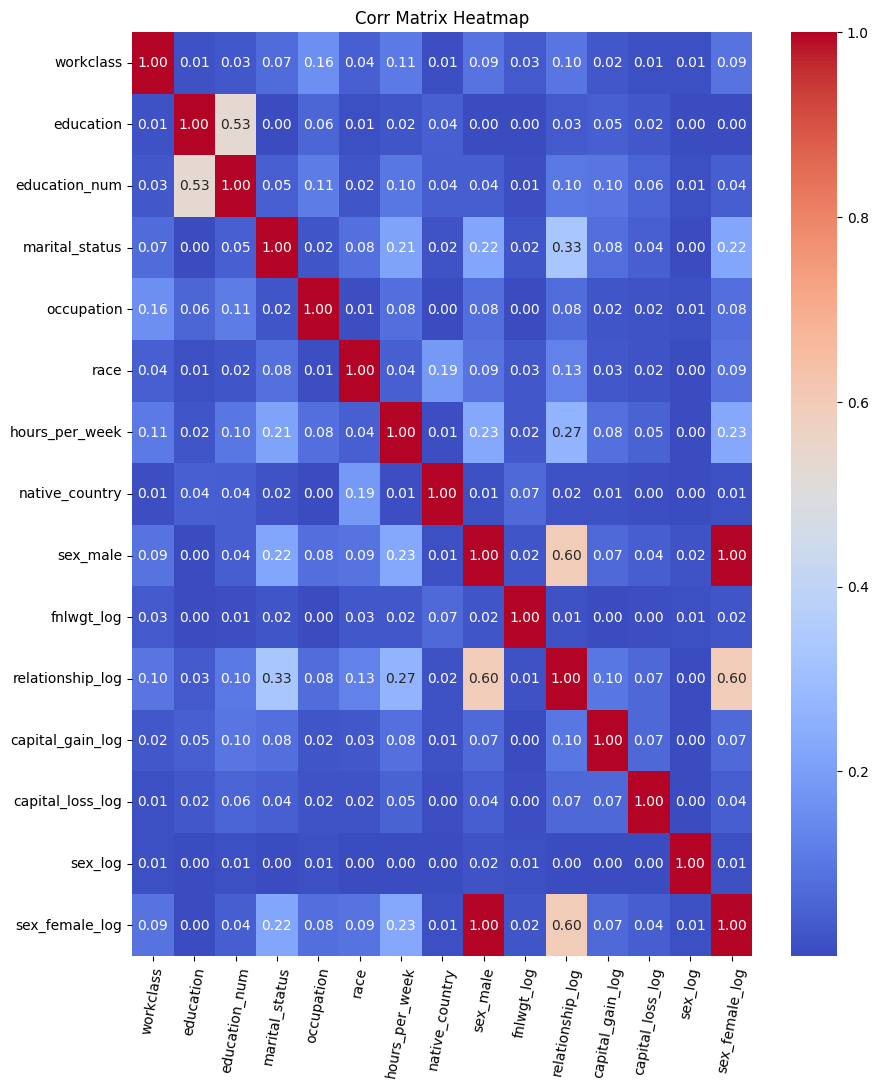

In [308]:
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.xticks(rotation=80) #rotate x -axis for 45 degree
plt.title('Corr Matrix Heatmap')
plt.show()

In [309]:
# FINDING LOW VARIANCES
from sklearn.feature_selection import VarianceThreshold

X = df_filtered.drop('income', axis=1)
y = df_filtered['income']

threshold = 0.01
selector = VarianceThreshold(threshold=threshold)
selector.fit(X)

# LOW VARIANCE COLUMNS
low_variance_features = X.columns[~selector.get_support()]
print("Low variance features to drop: ")
print(list(low_variance_features))

# DROP THE LOW VARIANCE COLUMNS 
X_filtered = X.drop(columns= low_variance_features)

# ADD TARGET BACK
df_final = pd.concat([X_filtered, y], axis=1)

print("Original shape: ", df_filtered.shape)
print("New filtered shape: ", df_final.shape)

Low variance features to drop: 
['sex_log']
Original shape:  (32539, 15)
New filtered shape:  (32539, 14)


In [310]:
df = df_final

In [311]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32539 entries, 0 to 32538
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   workclass         32539 non-null  int8   
 1   education         32539 non-null  int8   
 2   education_num     32539 non-null  int8   
 3   marital_status    32539 non-null  int8   
 4   occupation        32539 non-null  int8   
 5   race              32539 non-null  int8   
 6   hours_per_week    32539 non-null  int8   
 7   native_country    32539 non-null  int8   
 8   sex_male          32539 non-null  int8   
 9   fnlwgt_log        32539 non-null  float32
 10  relationship_log  32539 non-null  float16
 11  capital_gain_log  32539 non-null  float32
 12  capital_loss_log  32539 non-null  float32
 13  income            32539 non-null  int8   
dtypes: float16(1), float32(3), int8(10)
memory usage: 762.8 KB


In [312]:
# ADVANCED NEW FEATURE CREATIION 
df['monthly_hours'] = df['hours_per_week'] * 4
df['total_gain'] = df['capital_gain_log'] - df['capital_loss_log']

# TIME-BASED ROLLING & LAGGING 
df['income_rolling3'] = df.groupby('capital_gain_log')['income'].rolling(3).mean().reset_index(0, drop=True)
df['education_rolling3'] = (df.groupby('education')['income'].rolling(3).mean().reset_index(0, drop=True))
df['occupation_rolling3'] = (df.groupby('occupation')['income'].rolling(3).mean().reset_index(0, drop=True))

In [313]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32539 entries, 0 to 32538
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   workclass            32539 non-null  int8   
 1   education            32539 non-null  int8   
 2   education_num        32539 non-null  int8   
 3   marital_status       32539 non-null  int8   
 4   occupation           32539 non-null  int8   
 5   race                 32539 non-null  int8   
 6   hours_per_week       32539 non-null  int8   
 7   native_country       32539 non-null  int8   
 8   sex_male             32539 non-null  int8   
 9   fnlwgt_log           32539 non-null  float32
 10  relationship_log     32539 non-null  float16
 11  capital_gain_log     32539 non-null  float32
 12  capital_loss_log     32539 non-null  float32
 13  income               32539 non-null  int8   
 14  monthly_hours        32539 non-null  int8   
 15  total_gain           32539 non-null  float32
 1

In [314]:
# train_test_split
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# IMPROVED MODEL TRAINING 

1. DECISION TREE CLASSIFIER
2. RANDOM FOREST CLASSIFIER
3. XGBOOST CLASSIFIER

In [380]:
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
xgb_class = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1, 
    max_depth=5, 
    subsample=1, 
    colsample_bytree= 0.8, 
    random_state=42
)
# DECISION TREE
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
# RANDOM FOREST 
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
# XGBOOST
xgb_class.fit(X_train, y_train)
y_pred_xgb_class = xgb_class.predict(X_test)

In [382]:
# DECISION TREE AFTER FE  
class_report = accuracy_score(y_test, y_pred_dt)
con_matrix = confusion_matrix(y_test, y_pred_dt)
print(f"\n Classification report of Decision Tree: ")
print(class_report)
print(f"\n Confusion matrix of of Decision Tree: ")
print(con_matrix)


 Classification report of Decision Tree: 
0.9520590043023971

 Confusion matrix of of Decision Tree: 
[[4748  160]
 [ 152 1448]]


In [383]:
# RANDOM FOREST AFTER FE  
class_report = accuracy_score(y_test, y_pred_rf)
con_matrix = confusion_matrix(y_test, y_pred_rf)
print(f"\n Classification report of Random Forest: ")
print(class_report)
print(f"\n Confusion matrix of of Random Forest: ")
print(con_matrix)


 Classification report of Random Forest: 
0.9660417947141979

 Confusion matrix of of Random Forest: 
[[4761  147]
 [  74 1526]]


In [381]:
# XGBOOST AFTER FE  
class_report = accuracy_score(y_test, y_pred_xgb_class)
con_matrix = confusion_matrix(y_test, y_pred_xgb_class)
print(f"\n Classification report of XGBoost: ")
print(class_report)
print(f"\n Confusion matrix of of XGBoost: ")
print(con_matrix)


 Classification report of XGBoost: 
0.9674247080516287

 Confusion matrix of of XGBoost: 
[[4754  154]
 [  58 1542]]


# ALGORITHMS MUST BE SCALED BEFORE APPLYING FOR TRAINING AND TEST


1. LOGISTIC REGRESION 
2. SUPPORT VECTOR MACHINE 
3. KNN 

In [339]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lr = LogisticRegression() 
svc = SVC(C=1.0, kernel='rbf')
knn = KNeighborsClassifier()

In [343]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train_scaled = pd.DataFrame(
    imputer.fit_transform(X_train_scaled),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    imputer.fit_transform(X_test_scaled),
    columns=X_test.columns
)

In [344]:
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [345]:
y_pred_lr = lr.predict(X_test_scaled)

In [346]:
# LOGISTIC REGRESSION FE  
class_report = accuracy_score(y_test, y_pred_lr)
con_matrix = confusion_matrix(y_test, y_pred_lr)
print(f"\n Classification report of Logistic Regression: ")
print(class_report)
print(f"\n Confusion matrix of of Logistic Regression: ")
print(con_matrix)


 Classification report of Logistic Regression: 
0.9411493546404426

 Confusion matrix of of Logistic Regression: 
[[4765  143]
 [ 240 1360]]


In [347]:
# SUPPORT VECTOR MACHINE AFTER FE 
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)

In [348]:
# SUPPORT VECTOR MACHINE FE  
class_report = accuracy_score(y_test, y_pred_svc)
con_matrix = confusion_matrix(y_test, y_pred_svc)
print(f"\n Classification report of Support Vector Machine: ")
print(class_report)
print(f"\n Confusion matrix of of Support Vector Machine: ")
print(con_matrix)


 Classification report of Support Vector Machine: 
0.9580516287645974

 Confusion matrix of of Support Vector Machine: 
[[4738  170]
 [ 103 1497]]


In [349]:
# KNN AFTER FE 
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [350]:
# KNN FE  
class_report = accuracy_score(y_test, y_pred_knn)
con_matrix = confusion_matrix(y_test, y_pred_knn)
print(f"\n Classification report of KNN: ")
print(class_report)
print(f"\n Confusion matrix of of KNN: ")
print(con_matrix)


 Classification report of KNN: 
0.9431468961278426

 Confusion matrix of of KNN: 
[[4712  196]
 [ 174 1426]]


# THRESHOLD TUNNING AND ADVANCED METRICS OF LOGISTIC REGRESSION

In [352]:
probs = lr.predict_proba(X_test_scaled)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[0])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

Raw probabiliteis:  [2.85036285e-04 9.98497709e-01 1.21725428e-03]
Model confidence for positive class: 99.85%


In [364]:
# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_low, average='weighted'))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_med, average='weighted'))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_high, average='weighted'))


 === LOW THRESHOLD (0.3) ===
Predictions:  [1 1 1 ... 1 1 0]
Precision:  0.7089706831517285
Recall:  0.737861094038107

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [1 0 1 ... 1 1 0]
Precision:  0.7179857634682466
Recall:  0.7321757836508912

 === HIGH THRESHOLD (0.8) ===
Predictions:  [1 0 1 ... 1 1 0]
Precision:  0.7474954648467673
Recall:  0.6905347264904733


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being s

# THRESHOLD TUNNING AND ADVANCED METRICS OF DECISION TREE CLASSIFIER

In [366]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

probs = dt.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[10])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

Raw probabiliteis:  [0. 1. 0.]
Model confidence for positive class: 100.00%


In [370]:
# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_low, average='weighted'))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_med, average='weighted'))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_high, average='weighted'))


 === LOW THRESHOLD (0.3) ===
Predictions:  [1 0 1 ... 1 1 0]
Precision:  0.7316506370205078
Recall:  0.7295636140135218

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [1 0 1 ... 1 1 0]
Precision:  0.7316506370205078
Recall:  0.7295636140135218

 === HIGH THRESHOLD (0.8) ===
Predictions:  [1 0 1 ... 1 1 0]
Precision:  0.7316506370205078
Recall:  0.7295636140135218


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being s

# RANDOM FOREST CLASSIFIER AFTER FE AND FS


In [372]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

probs = rf.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[10])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_low, average='weighted'))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_med, average='weighted'))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_high, average='weighted'))


Raw probabiliteis:  [0. 1. 0.]
Model confidence for positive class: 100.00%

 === LOW THRESHOLD (0.3) ===
Predictions:  [1 1 1 ... 1 1 0]
Precision:  0.7282688615169882
Recall:  0.7393976644130301

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [1 1 1 ... 1 1 0]
Precision:  0.7433796458357924
Recall:  0.7318684695759066

 === HIGH THRESHOLD (0.8) ===
Predictions:  [1 1 1 ... 1 1 0]
Precision:  0.7518970696433073
Recall:  0.7183466502765826


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being s

# SUPPORT VECTOR MACHINE CLASSIFIER AFTER FE AND FS

In [373]:
svc = SVC(kernel='rbf', C=1.0, probability=True)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)

probs = svc.predict_proba(X_test_scaled)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[10])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_low, average='weighted'))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_med, average='weighted'))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_high, average='weighted'))

Raw probabiliteis:  [2.96233391e-07 9.99515971e-01 4.83733168e-04]
Model confidence for positive class: 99.95%

 === LOW THRESHOLD (0.3) ===
Predictions:  [1 1 1 ... 1 1 0]
Precision:  0.7143942430958302
Recall:  0.7400122925629994

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [1 0 1 ... 1 1 0]
Precision:  0.7360156938590993
Recall:  0.7297172710510141

 === HIGH THRESHOLD (0.8) ===
Predictions:  [1 0 1 ... 1 1 0]
Precision:  0.7463320396191615
Recall:  0.7042102028272895


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being s

# XGBOOST CLASSIFIER AFTER FE AND FS

In [374]:
xgb_class = xgb.XGBClassifier(
    n_estimators = 130,
    learning_rate=0.01,
    max_depth = 3,
    subsample = 1, 
    colsample_bytree = 0.8,
    random_state = 42
)

xgb_class.fit(X_train, y_train)
y_pred_xgb_class = xgb_class.predict(X_test)

probs = xgb_class.predict_proba(X_test)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[10])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_low, average='weighted'))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_med, average='weighted'))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_high, average='weighted'))

Raw probabiliteis:  [2.1055217e-04 9.3334985e-01 6.6439524e-02]
Model confidence for positive class: 93.47%

 === LOW THRESHOLD (0.3) ===
Predictions:  [1 1 1 ... 1 1 1]
Precision:  0.5906535310504961
Recall:  0.753841425937308

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [1 1 1 ... 1 1 0]
Precision:  0.7364004005487498
Recall:  0.7267977873386601

 === HIGH THRESHOLD (0.8) ===
Predictions:  [1 0 1 ... 1 1 0]
Precision:  0.7541487400122926
Recall:  0.6994468346650277


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being s

# KNN CLASSIFIER AFTER FE AND FS

In [376]:
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

probs = knn.predict_proba(X_test_scaled)
positive_probs = probs[:, 1]
print("Raw probabiliteis: ", probs[10])
print(f"Model confidence for positive class: {positive_probs[0]*100:.2f}%")

# 1. LOW THRESHOLD (0.3)
low_thr = 0.3
y_pred_low = (positive_probs >= low_thr).astype(int)
print('\n === LOW THRESHOLD (0.3) ===')
print('Predictions: ', y_pred_low)
print('Precision: ', precision_score(y_test, y_pred_low, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_low, average='weighted'))

# 2. MEDIUM THRESHOLD (0.5)
med_thr = 0.5
y_pred_med = (positive_probs >= med_thr).astype(int)
print('\n === MEDIUM THRESHOLD (0.5) ===')
print('Predictions: ', y_pred_med)
print('Precision: ', precision_score(y_test, y_pred_med, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_med, average='weighted'))

# 3. HIGH THRESHOLD (0.8)
high_thr = 0.8
y_pred_high = (positive_probs >= high_thr).astype(int)
print('\n === HIGH THRESHOLD (0.8) ===')
print('Predictions: ', y_pred_high)
print('Precision: ', precision_score(y_test, y_pred_high, average='weighted'))
print('Recall: ', recall_score(y_test, y_pred_high, average='weighted'))

Raw probabiliteis:  [0. 1. 0.]
Model confidence for positive class: 100.00%

 === LOW THRESHOLD (0.3) ===
Predictions:  [1 1 1 ... 1 1 0]
Precision:  0.7064625199178385
Recall:  0.7375537799631223

 === MEDIUM THRESHOLD (0.5) ===
Predictions:  [1 1 1 ... 1 1 0]
Precision:  0.7272920308919203
Recall:  0.7240319606637984

 === HIGH THRESHOLD (0.8) ===
Predictions:  [1 1 1 ... 1 1 0]
Precision:  0.7405136788497801
Recall:  0.7009834050399508


/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/murodjongafforov/Desktop/Model Improvement New Era of SML/1-dars /3-dars/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being s

# TABULATE AFTER FE 

In [385]:
from tabulate import tabulate

results_improvement = [
    ['Logistic Regression', 0.941],
    ['Decision Tree Classifier', 0.952],
    ['Random Forest Classifier',0.966],
    ['SVC',0.958],
    ['XGBClassifier',0.967],
    ['KNN', 0.943]
    
]
headers = ['Models', 'accuracy']
table = tabulate(results_improvement, headers=headers, tablefmt='grid', floatfmt='.3f')
print('\n===============================================================================')
print(table)
print('===============================================================================')


+--------------------------+------------+
| Models                   |   accuracy |
+==========================+============+
| Logistic Regression      |      0.941 |
+--------------------------+------------+
| Decision Tree Classifier |      0.952 |
+--------------------------+------------+
| Random Forest Classifier |      0.966 |
+--------------------------+------------+
| SVC                      |      0.958 |
+--------------------------+------------+
| XGBClassifier            |      0.967 |
+--------------------------+------------+
| KNN                      |      0.943 |
+--------------------------+------------+


In [387]:
best_score = max(model[1] for model in results_improvement)  # this takes the maximum values
best_models = []  # we will store the best models here

for model in results_improvement:
    # if model[1] equals the best score and model name matches
    if model[1] == best_score and model[0] in ['XGBClassifier']:
        # append to best_models list
        best_models.append(model)

for model in best_models:
    print(f'Best model after FE and FS: {model[0]}, best accuracy is: {model[1]} which is 96.7%')

Best model after FE and FS: XGBClassifier, best accuracy is: 0.967 which is 96.7%


In [389]:
best_score = max(model[1] for model in results_baseline)  # this takes the maximum values
best_models = []  # we will store the best models here

for model in results_baseline:
    # if model[1] equals the best score and model name matches
    if model[1] == best_score and model[0] in ['Random Forest Classifier']:
        # append to best_models list
        best_models.append(model)

for model in best_models:
    print(f'Best model: {model[0]}, best accuracy is: {model[1]} which is 85%')

Best model: Random Forest Classifier, best accuracy is: 0.85 which is 85%




# After applying feature engineering, the accuracy increased from 85% to 96.7% by 11.7 % which represents an improvement of 11.7%.



# BEST MODEL USING JOBLIB FOR FUTURE USE

In [391]:
from joblib import dump, load
dump(y_pred_xgb_class, 'best_model_xgboost.joblib')

['best_model_xgboost.joblib']